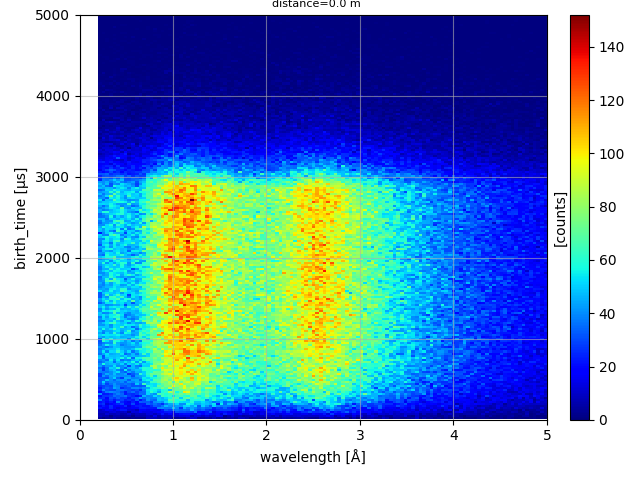

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
import tof

source = tof.Source(facility="ess", neutrons=1_000_000)
da = source.data.squeeze()

fig, ax = plt.subplots()
p = da.hist(birth_time=200, wavelength=500).plot(cmap="jet", ax=ax)
ax.set_title(str(source), fontsize=8)
ax.set_xlim([0, 5])
ax.set_ylim([0, 5000])
ax.grid(alpha=0.6)

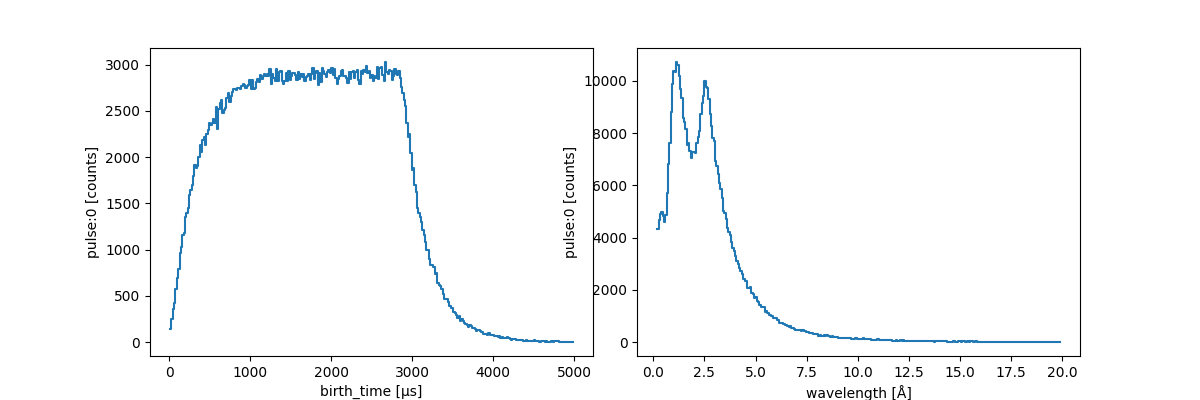

In [2]:
source = tof.Source(facility="ess", neutrons=500_000)
source.plot()

In [3]:
from drtrex.components.source import Source
from drtrex.instrument import Instrument

central_wavelength = sc.scalar(1.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
T_OFFSET = sc.scalar(1.7, unit="ms")
trex = Instrument(wavelength=central_wavelength, rrm=rrm, t_offset=T_OFFSET)
mask = trex.mask_from_choppers("Monochromatic Chopper 2")
# mask = trex.mask_from_chopper("Bandwidth Chopper 2")

source = Source(facility="ess", neutrons=1_000_000)
source.apply_mask(mask)
print(source.data)

<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:3718, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [2308.19, 966.601, ..., 506.979, 740.825]
* distance                  float64              [m]  ()  0
* eto                       float64            [µs]  (pulse, event)  [2308.19, 966.601, ..., 506.979, 740.825]
* id                          int64        <no unit>  (pulse, event)  [380, 439, ..., 999243, 999352]
* speed                     float64            [m/s]  (pulse, event)  [2662.74, 2023.86, ..., 2262.59, 2597.79]
* toa                       float64            [µs]  (pulse, event)  [2308.19, 966.601, ..., 506.979, 740.825]
* wavelength                float64             [Å]  (pulse, event)  [1.4857, 1.9547, ..., 1.74845, 1.52284]
Data:
                            float64         [counts]  (pulse, event)  [1, 1, ..., 1, 1]




In [4]:
flux = trex.estimate_flux()
flux

<scipp.Variable> (rrm: 7)      int64         [counts]  [226, 806, ..., 565, 206]